In [2]:
import os
import sys
import time
import intake
from tqdm import tqdm
import xarray as xr
import pandas as pd
import numpy as np
import pickle
from datetime import datetime
import metpy.calc as mpcalc
from metpy.units import units
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta


from dask.distributed import Client, LocalCluster

os.environ['WXSYSLIBDIR']='/g/data/gb02/mb0427/WxSysLib'
sys.path.append(os.environ['WXSYSLIBDIR'])
os.environ['SWTLIBDIR']='/home/565/mb0427/gdata-gb02/Australian_synoptic_weather_types'
sys.path.append(os.environ['SWTLIBDIR'])

In [13]:
# START_YEAR = 1980
START_YEAR = 1980
END_YEAR = 2020

OUTPUT_DIR = '/g/data/nf33/nk2247/wind_droughts/GC26_energy_synoptics/dev/wind_drought/'

In [20]:
THRESHOLD = 10

# Specify path of capacity factor data
cf_path = f'{OUTPUT_DIR}wind_capacity_factor_van_der_Wiel_era5_hourly_{START_YEAR}_{END_YEAR}_below_{THRESHOLD}percent_Aus.nc'

# Read capacity factor data
cf_ds = xr.open_dataset(
    cf_path,
    chunks={"time": 365*5}
)

In [9]:
SWTpath='/g/data/gb02/mb0427/Australian_synoptic_weather_types/'
clusters=xr.open_dataset(SWTpath+"SWT_climatology/SWT_climatology.nc")
clusters=clusters.sel(time=slice(datetime(START_YEAR,1,1),datetime(END_YEAR,12,31,23)))
clusters["time"] = clusters["time"] - np.timedelta64(12, "h")
SWTnames = clusters.SWTs

In [10]:
clusters=pd.read_csv(f"{SWTpath}SWT_climatology/SWT_climatology.csv")
times=[datetime.strptime(t,'%Y-%m-%d') for t in clusters.time.to_list()]
clusters['time']=times
clusters=clusters[clusters.time>=datetime(START_YEAR,1,1)]
clusters=clusters[clusters.time<=datetime(END_YEAR,12,31)]

# Capacity factor below threshold

100%|██████████| 30/30 [02:07<00:00,  4.25s/it]


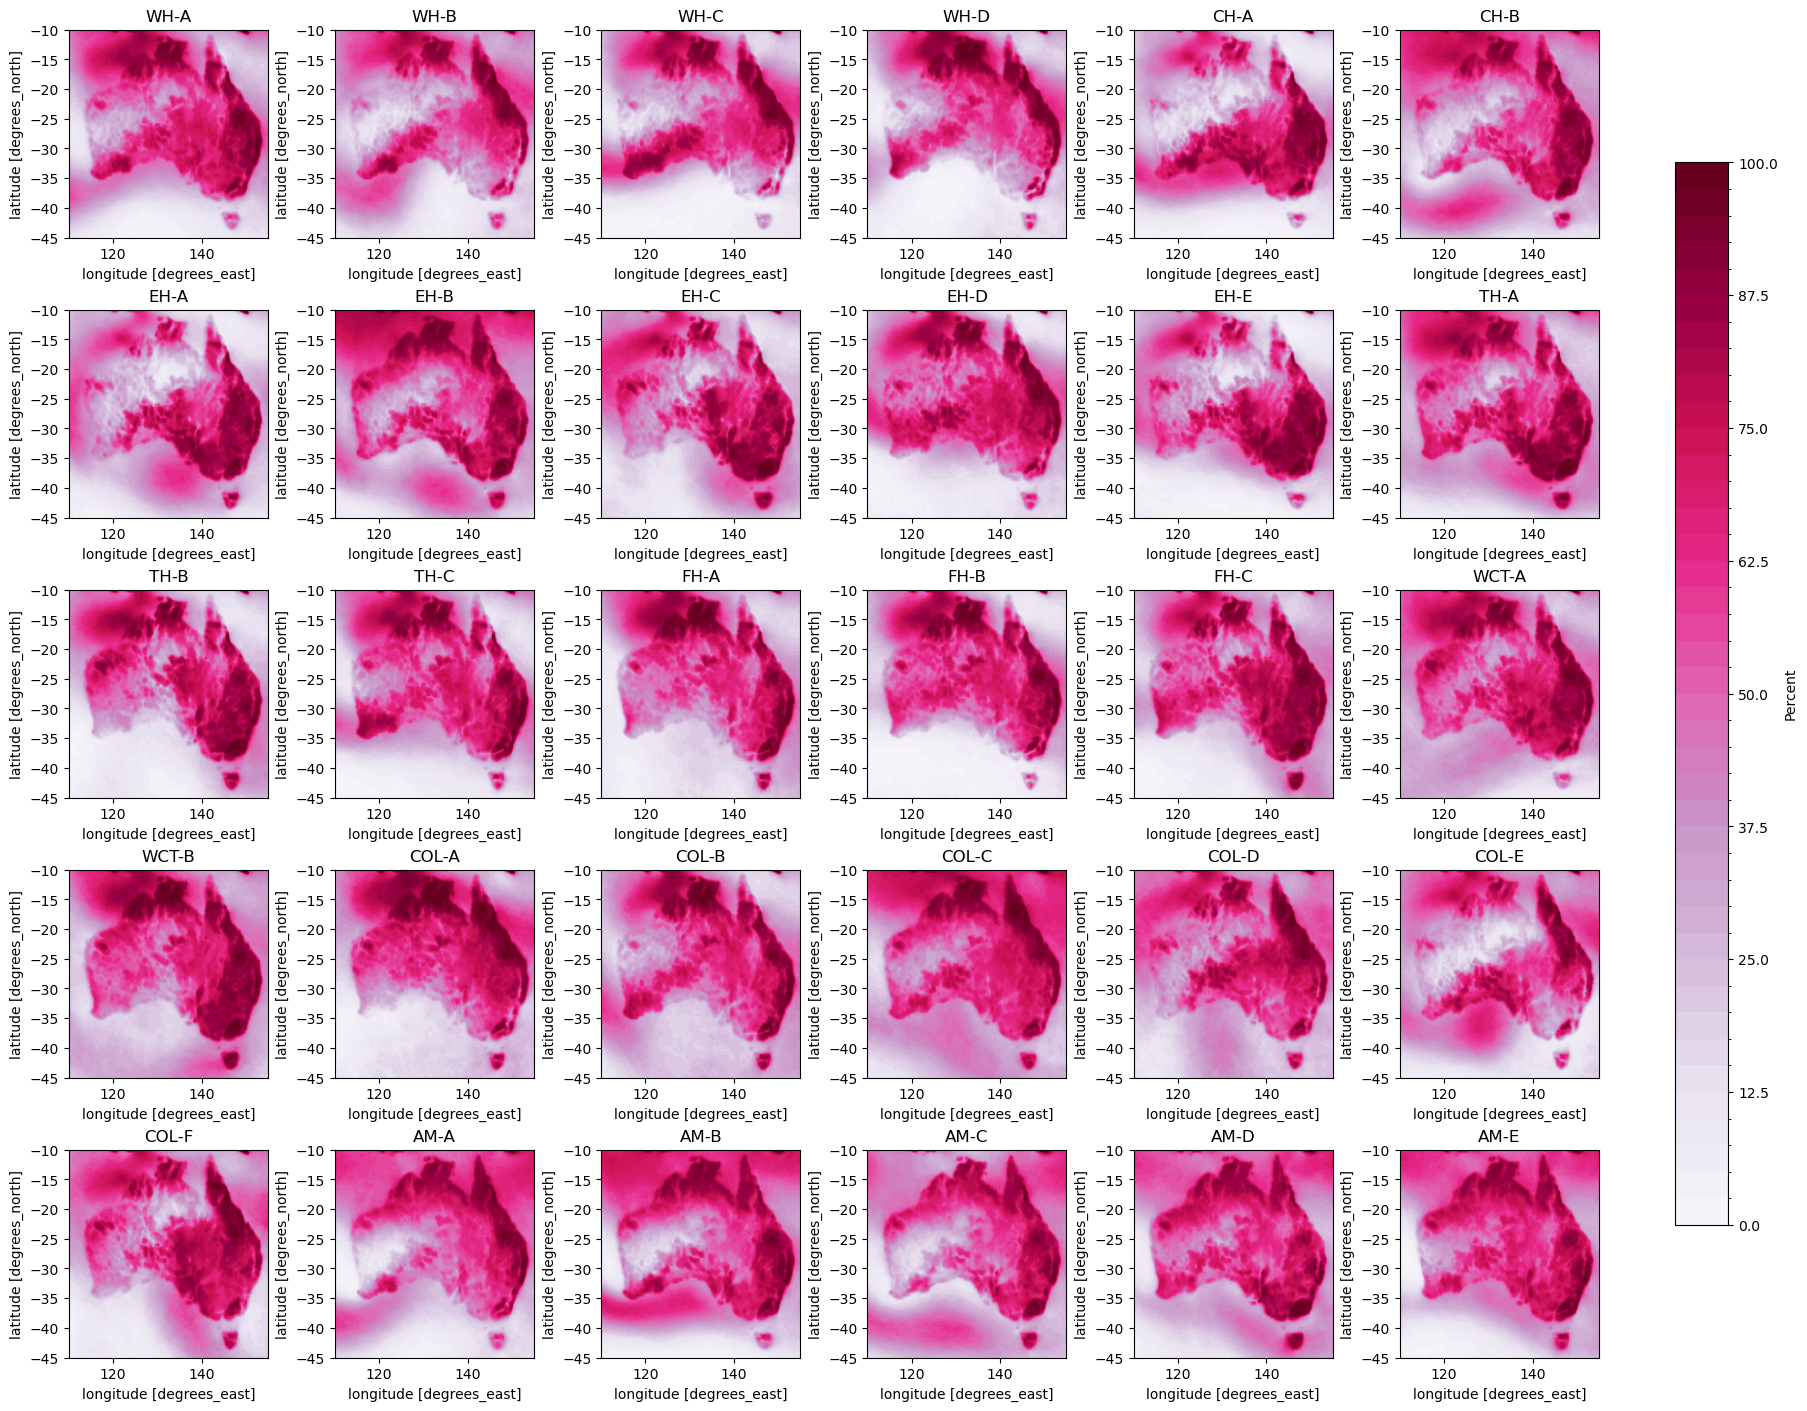

In [17]:
var = 'capacity_factor'
name = f'{START_YEAR}_{END_YEAR}_below_{THRESHOLD}percent_SWT'
levels = np.linspace(0, 100, 41)

fig, axes = plt.subplots(5, 6, figsize=(18, 14), constrained_layout=True)
axes = axes.flatten()

mappable = None

for i, SWTname in enumerate(tqdm(SWTnames)):
    SWT_i = clusters[clusters.assigned_SWT == SWTname]
    ds_i = cf_ds.sel(time=SWT_i.time.to_list())
    ds_i_clim = (ds_i[var].sum(dim="time") / len(ds_i.time)) * 100

    ax = axes[i]
    mappable = ds_i_clim.plot.contourf(
        ax=ax,
        levels=levels,
        cmap="PuRd",
        vmin=0,
        vmax=100,
        add_colorbar=False
    )
    ax.set_title(str(SWTname.item()))

for j in range(len(SWTnames), len(axes)):
    axes[j].set_visible(False)

fig.colorbar(mappable, ax=axes, shrink=0.8, label="Percent")

outfile=f"{OUTPUT_DIR}/{var}_{name}.png"
fig.savefig(outfile, dpi=600)
plt.show()

In [18]:
THRESHOLD = 20

# Specify path of capacity factor data
cf_path = f'{OUTPUT_DIR}wind_capacity_factor_van_der_Wiel_era5_hourly_{START_YEAR}_{END_YEAR}_below_{THRESHOLD}percent_Aus.nc'

# Read capacity factor data
cf_ds = xr.open_dataset(
    cf_path,
    chunks={"time": 365*5}
)

100%|██████████| 30/30 [02:20<00:00,  4.67s/it]


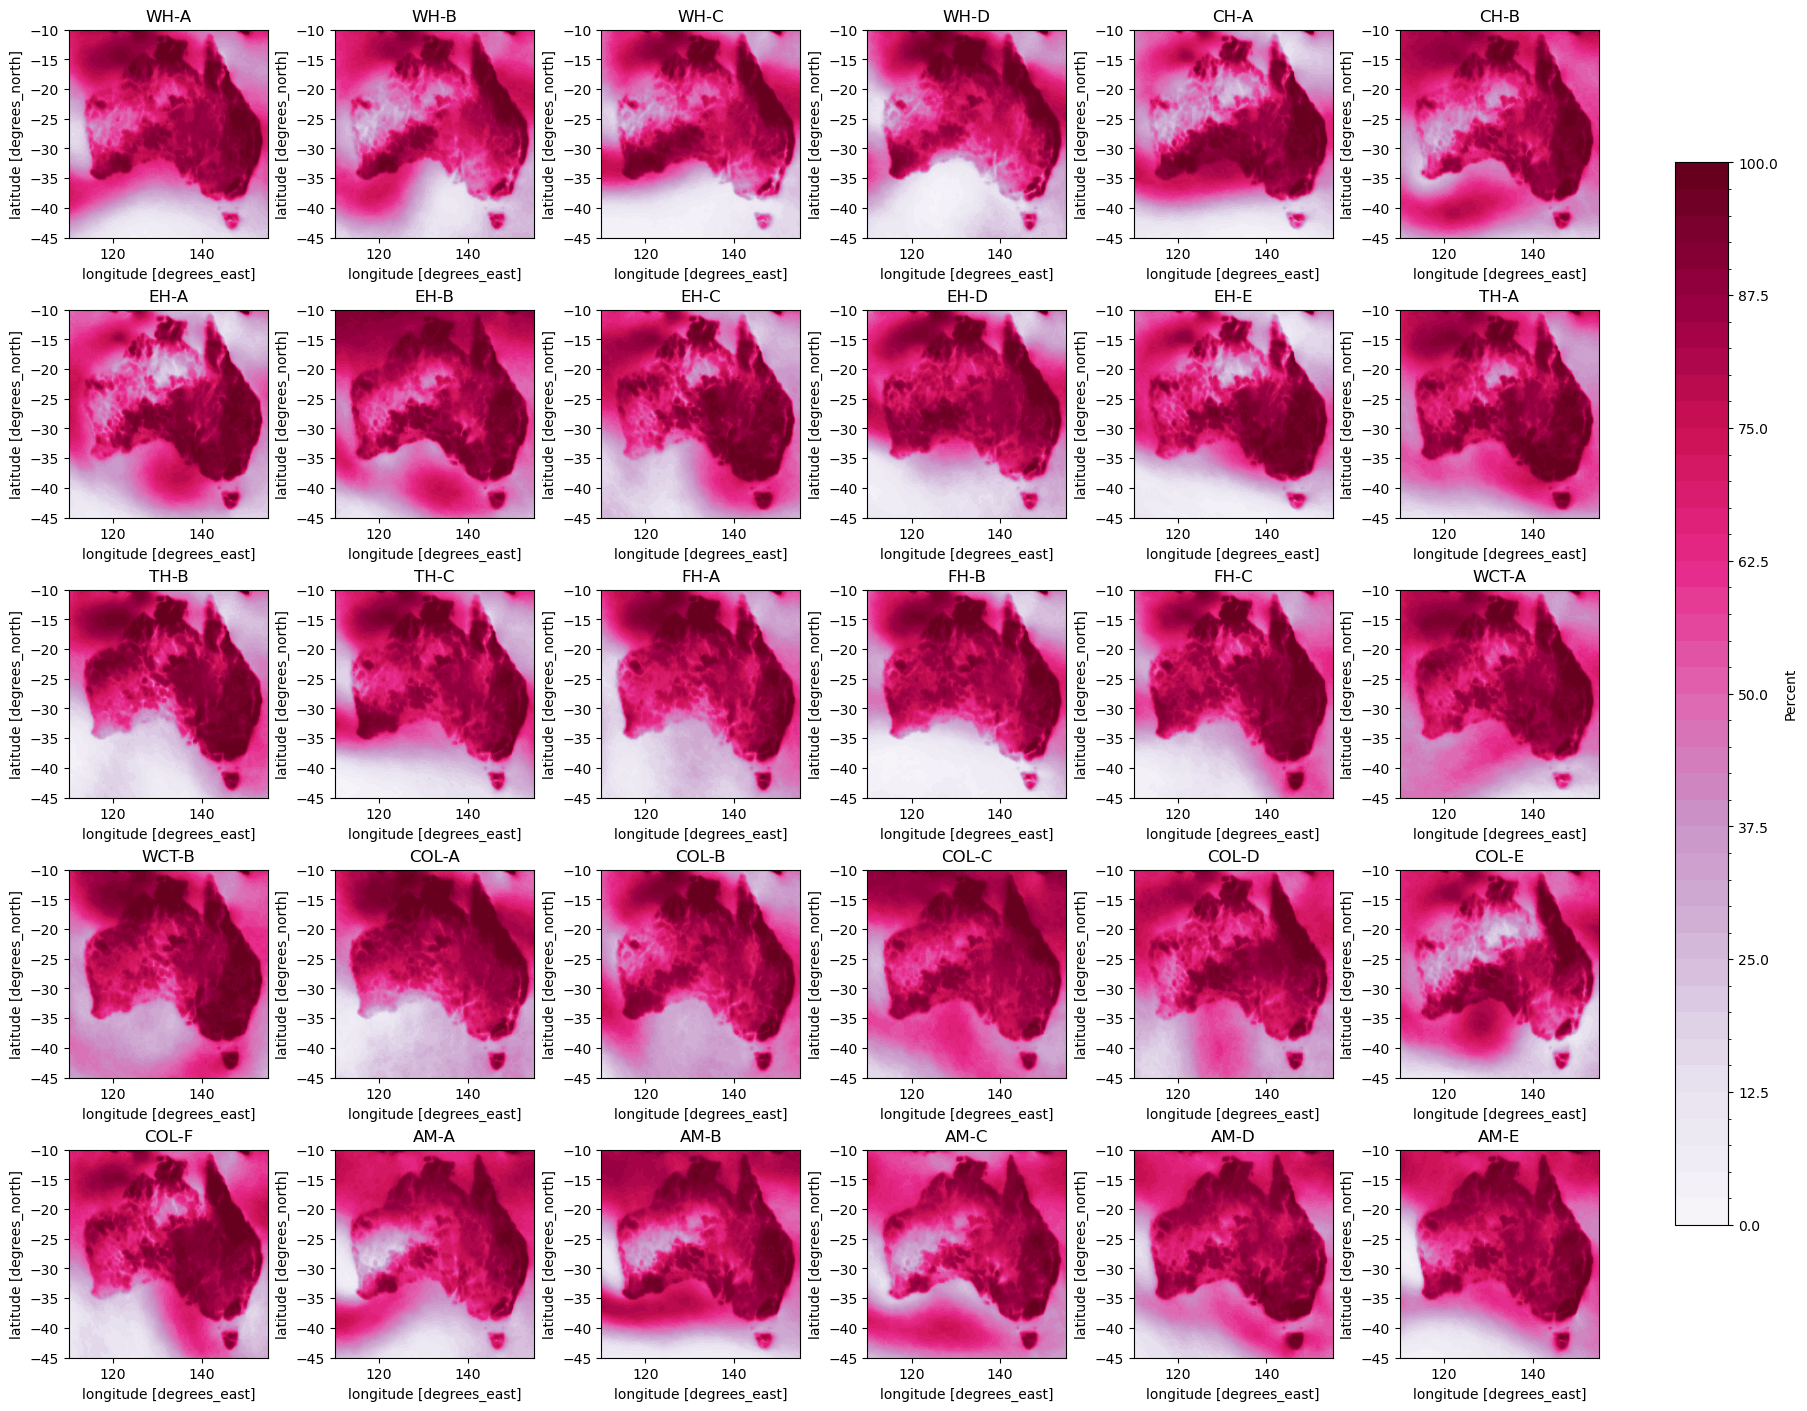

In [19]:
var = 'capacity_factor'
name = f'{START_YEAR}_{END_YEAR}_below_{THRESHOLD}percent_SWT'
levels = np.linspace(0, 100, 41)

fig, axes = plt.subplots(5, 6, figsize=(18, 14), constrained_layout=True)
axes = axes.flatten()

mappable = None

for i, SWTname in enumerate(tqdm(SWTnames)):
    SWT_i = clusters[clusters.assigned_SWT == SWTname]
    ds_i = cf_ds.sel(time=SWT_i.time.to_list())
    ds_i_clim = (ds_i[var].sum(dim="time") / len(ds_i.time)) * 100

    ax = axes[i]
    mappable = ds_i_clim.plot.contourf(
        ax=ax,
        levels=levels,
        cmap="PuRd",
        vmin=0,
        vmax=100,
        add_colorbar=False
    )
    ax.set_title(str(SWTname.item()))

for j in range(len(SWTnames), len(axes)):
    axes[j].set_visible(False)

fig.colorbar(mappable, ax=axes, shrink=0.8, label="Percent")

outfile=f"{OUTPUT_DIR}/{var}_{name}.png"
fig.savefig(outfile, dpi=600)
plt.show()

## Case study: Cathedral rocks

In [23]:
# Cathedral rocks - Energy Australia owned (50% equity)
lat = -34.849635
lon = 135.581802

cath_rocks = cf_ds.sel(lat=lat, lon=lon, method='nearest')

In [86]:
cath_rocks

<xarray.Dataset> Size: 3MB
Dimensions:          (time: 359424)
Coordinates:
  * time             (time) datetime64[ns] 3MB 1980-01-01 ... 2020-12-31T23:0...
    lon              float32 4B 135.5
    lat              float32 4B -34.75
Data variables:
    capacity_factor  (time) bool 359kB dask.array<chunksize=(1825,), meta=np.ndarray>

In [108]:
var = 'capacity_factor'
percentage_by_SWT = {}
for i, SWTname in enumerate(tqdm(SWTnames)):
    SWT_i = clusters[clusters.assigned_SWT == SWTname]
    ds_i = cath_rocks.sel(time=SWT_i.time.to_list())
    ds_i_clim = ( ds_i[var].sum(dim="time") / len(ds_i.time)) * 100
    SWT_name_str = str(SWTname['SWTs'].to_numpy())
    percentage_by_SWT[SWT_name_str] = ds_i_clim.compute()

100%|██████████| 30/30 [01:11<00:00,  2.39s/it]


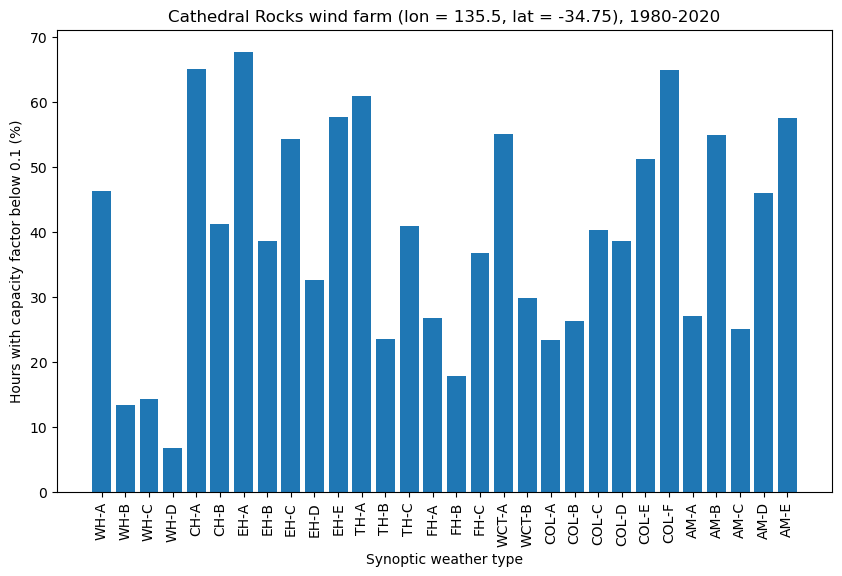

In [119]:
fig = plt.figure(figsize=(10,6))
plt.bar(percentage_by_SWT.keys(), percentage_by_SWT.values())
plt.ylabel('Hours with capacity factor below 0.1 (%)')
plt.title(f'Cathedral Rocks wind farm (lon = {cath_rocks.lon.values}, lat = {cath_rocks.lat.values}), {START_YEAR}-{END_YEAR}')
plt.xticks(rotation=90)
plt.xlabel('Synoptic weather type')
plt.show()

# Capacity Factor wind drought

In [113]:
DATA_DIR = '/g/data/nf33/nk2247/wind_droughts/GC26_energy_synoptics/data/output/era5_wind_drought_binary/'
cf_drought_file = f'{DATA_DIR}wind_drought_binary_cf_1980_2020.nc'
cf_drought = xr.open_dataset(cf_drought_file)

100%|██████████| 30/30 [1:00:37<00:00, 121.24s/it]


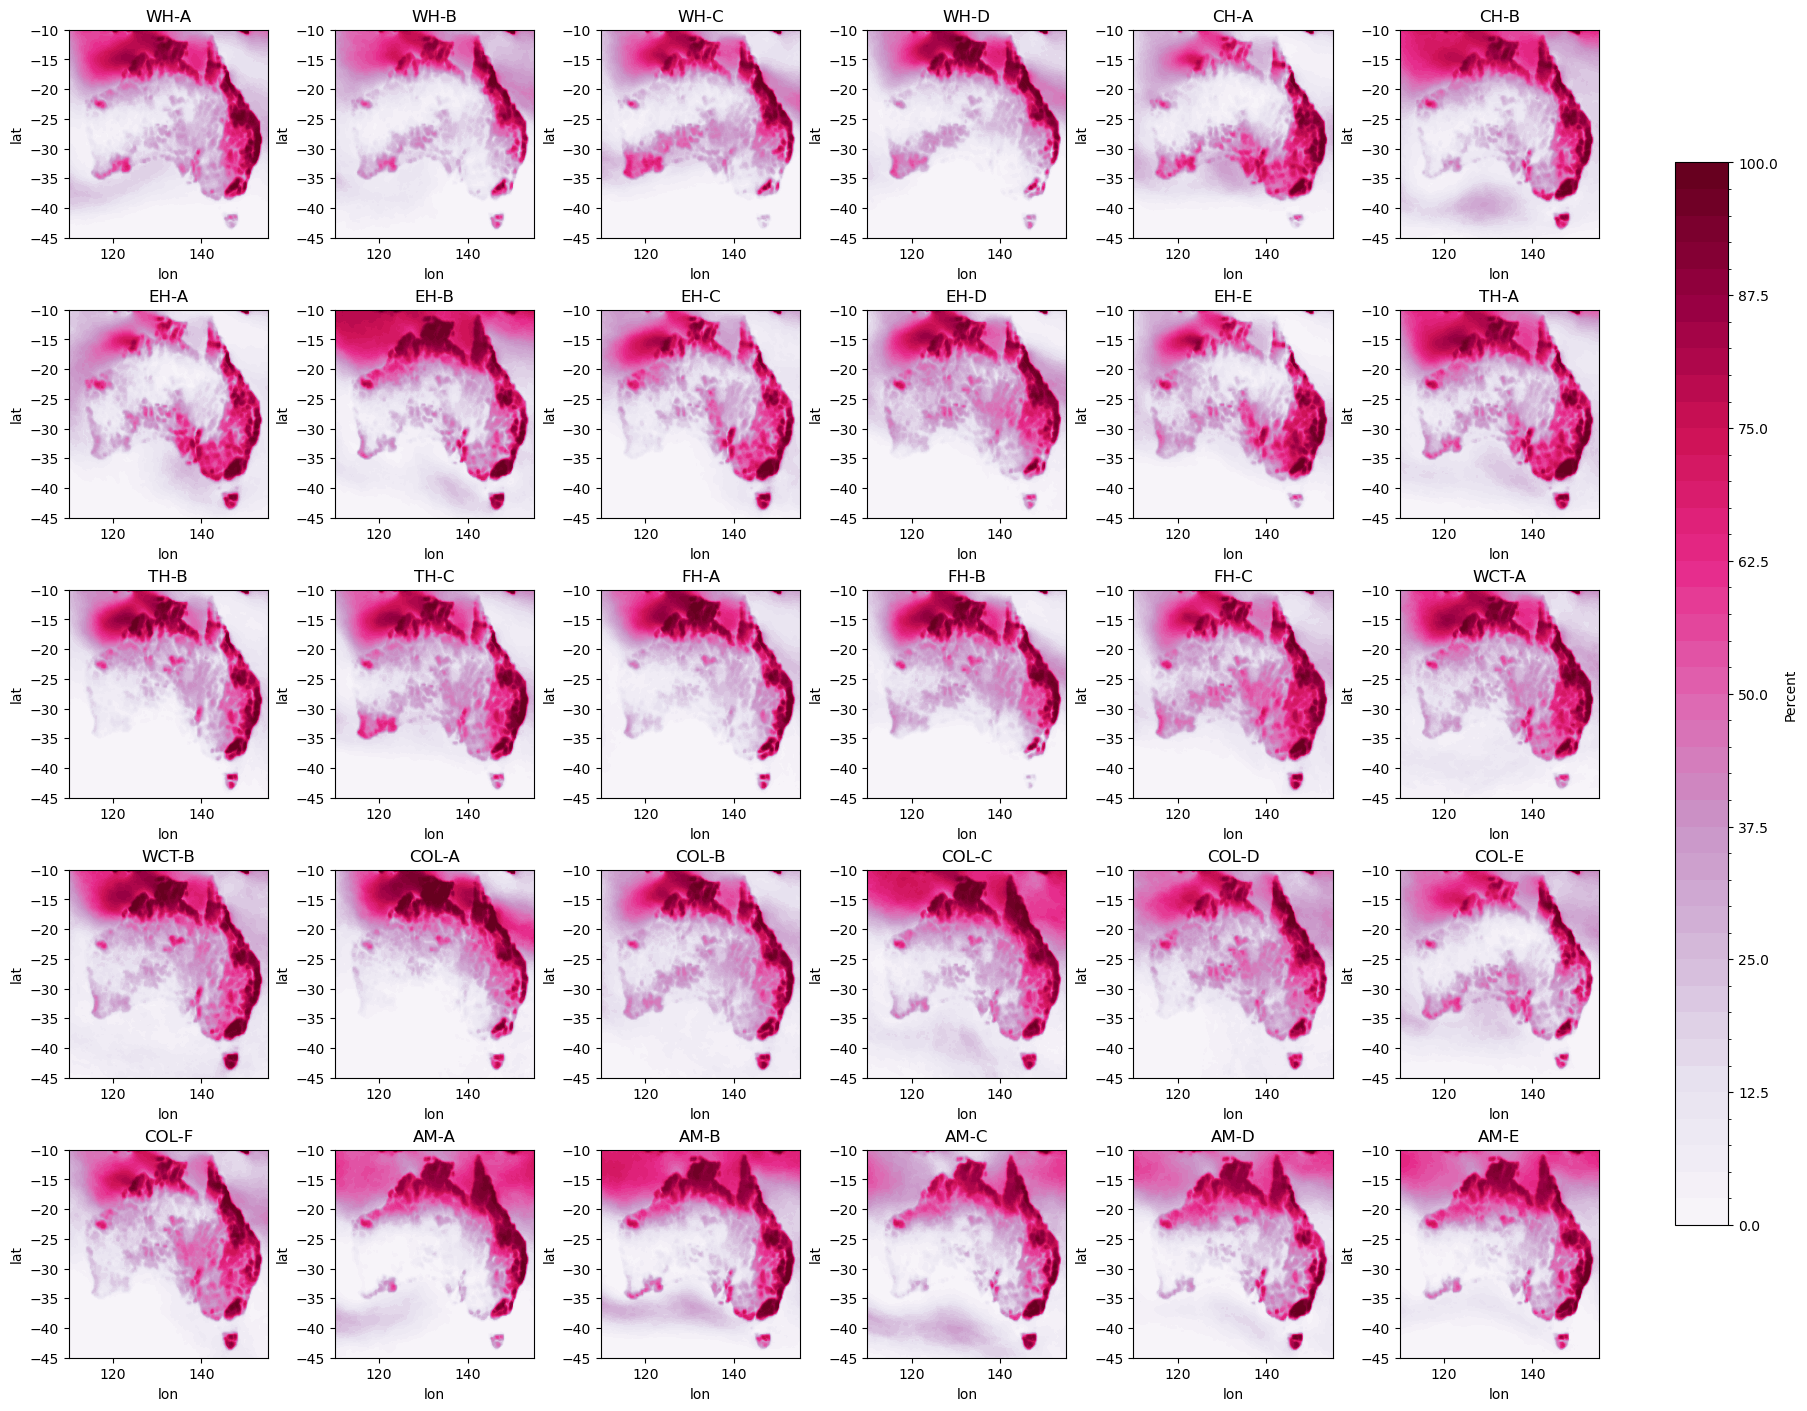

In [114]:
var = 'cf_drought_010'
name = f'{START_YEAR}_{END_YEAR}_{var}_SWT'
levels = np.linspace(0, 100, 41)

fig, axes = plt.subplots(5, 6, figsize=(18, 14), constrained_layout=True)
axes = axes.flatten()

mappable = None

for i, SWTname in enumerate(tqdm(SWTnames)):
    SWT_i = clusters[clusters.assigned_SWT == SWTname]
    ds_i = cf_drought.sel(time=SWT_i.time.to_list())
    ds_i_clim = (ds_i[var].sum(dim="time") / len(ds_i.time)) * 100

    ax = axes[i]
    mappable = ds_i_clim.plot.contourf(
        ax=ax,
        levels=levels,
        cmap="PuRd",
        vmin=0,
        vmax=100,
        add_colorbar=False
    )
    ax.set_title(str(SWTname.item()))

for j in range(len(SWTnames), len(axes)):
    axes[j].set_visible(False)

fig.colorbar(mappable, ax=axes, shrink=0.8, label="Percent")

outfile=f"{OUTPUT_DIR}/{var}_{name}.png"
fig.savefig(outfile, dpi=600)
plt.show()

## Case study: Cathedral Rocks wind farm

In [95]:
cf_drought_cath_rocks = cf_drought.sel(lat=lat, lon=lon, method='nearest')

In [99]:
cf_drought_cath_rocks

<xarray.Dataset> Size: 165kB
Dimensions:         (time: 14976)
Coordinates:
  * time            (time) datetime64[ns] 120kB 1980-01-01 ... 2020-12-31
    lat             float32 4B -34.75
    lon             float32 4B 135.5
Data variables:
    cf_drought_010  (time) int8 15kB ...
    cf_drought_020  (time) int8 15kB ...
    cf_drought_025  (time) int8 15kB ...
Attributes:
    title:            Daily binary wind drought flags — van der Wiel capacity...
    source:           ERA5-based wind capacity factor, van der Wiel et al.
    period:           1980-2020
    min_consec_days:  3
    methodology:      Daily mean capacity factor computed from hourly van der...
    institution:      NCI / Australian National University
    contact:          qr1706

In [105]:
var = 'cf_drought_010'
drought_percentage_by_SWT = {}
for i, SWTname in enumerate(tqdm(SWTnames)):
    SWT_i = clusters[clusters.assigned_SWT == SWTname]
    ds_i = cf_drought_cath_rocks.sel(time=SWT_i.time.to_list())
    ds_i_clim = ( ds_i[var].sum(dim="time") / len(ds_i.time)) * 100
    SWT_name_str = str(SWTname['SWTs'].to_numpy())
    drought_percentage_by_SWT[SWT_name_str] = ds_i_clim.compute()

100%|██████████| 30/30 [00:23<00:00,  1.27it/s]


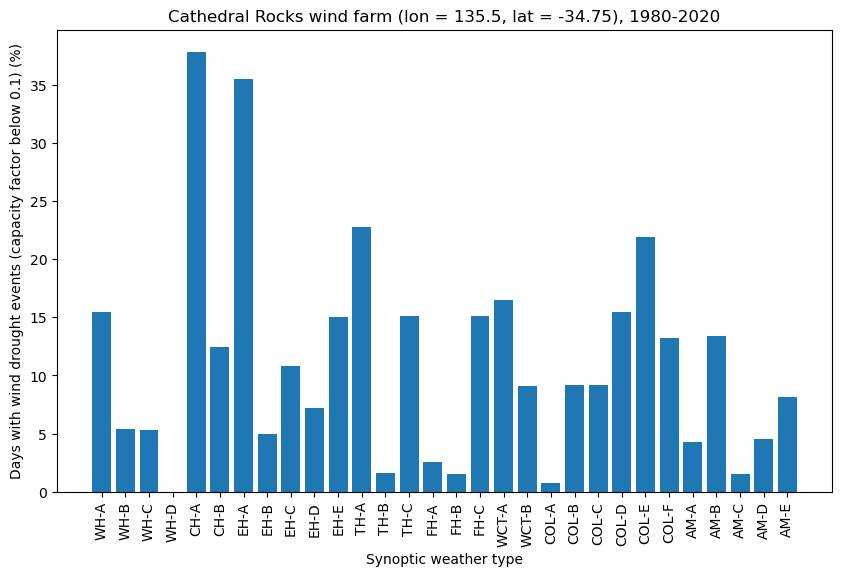

In [122]:
fig = plt.figure(figsize=(10,6))
plt.bar(drought_percentage_by_SWT.keys(), drought_percentage_by_SWT.values())
plt.ylabel('Days with wind drought events (capacity factor below 0.1) (%)')
plt.title(f'Cathedral Rocks wind farm (lon = {cath_rocks.lon.values}, lat = {cath_rocks.lat.values}), {START_YEAR}-{END_YEAR}')
plt.xticks(rotation=90)
plt.xlabel('Synoptic weather type')
plt.show()

In [115]:
var = 'cf_drought_010'
drought_count_by_SWT = {}
for i, SWTname in enumerate(tqdm(SWTnames)):
    SWT_i = clusters[clusters.assigned_SWT == SWTname]
    ds_i = cf_drought_cath_rocks.sel(time=SWT_i.time.to_list())
    ds_i_clim = ds_i[var].sum(dim="time")
    SWT_name_str = str(SWTname['SWTs'].to_numpy())
    drought_count_by_SWT[SWT_name_str] = ds_i_clim.compute()

100%|██████████| 30/30 [00:22<00:00,  1.35it/s]


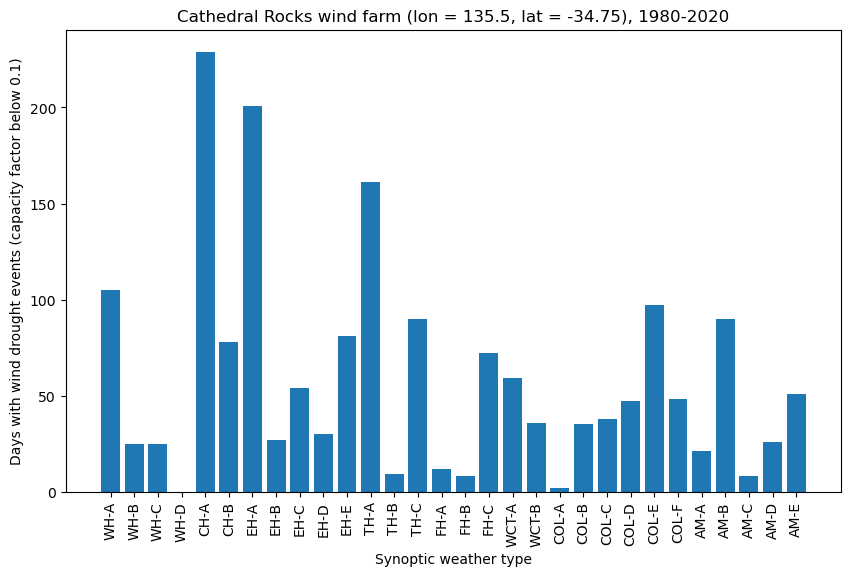

In [123]:
fig = plt.figure(figsize=(10,6))
plt.bar(drought_count_by_SWT.keys(), drought_count_by_SWT.values())
plt.ylabel('Days with wind drought events (capacity factor below 0.1)')
plt.title(f'Cathedral Rocks wind farm (lon = {cath_rocks.lon.values}, lat = {cath_rocks.lat.values}), {START_YEAR}-{END_YEAR}')
plt.xticks(rotation=90)
plt.xlabel('Synoptic weather type')
plt.show()

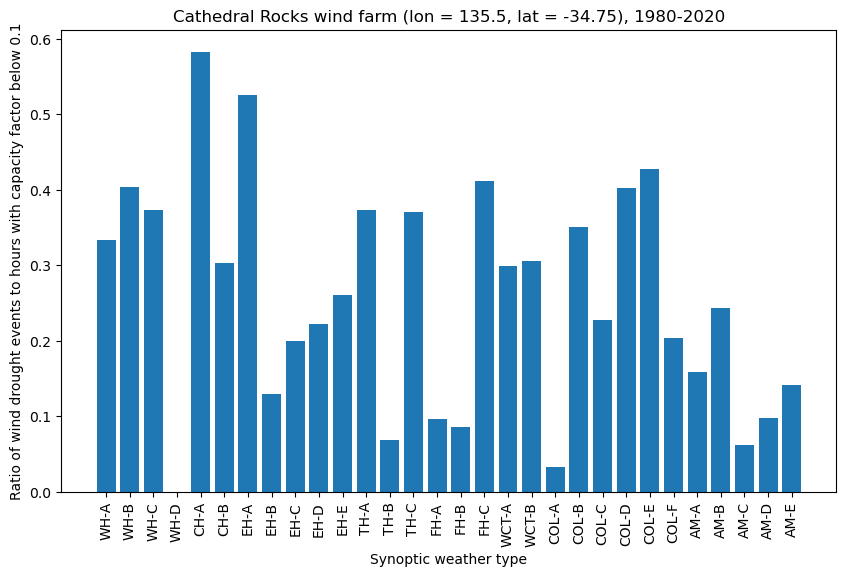

In [125]:
fig = plt.figure(figsize=(10,6))
plt.bar(drought_percentage_by_SWT.keys(), [drought_percentage_by_SWT[k]/percentage_by_SWT[k] for k in drought_percentage_by_SWT.keys()])
plt.ylabel('Ratio of wind drought events to hours with capacity factor below 0.1')
plt.title(f'Cathedral Rocks wind farm (lon = {cath_rocks.lon.values}, lat = {cath_rocks.lat.values}), {START_YEAR}-{END_YEAR}')
plt.xticks(rotation=90)
plt.xlabel('Synoptic weather type')
plt.show()

In [133]:
var = 'cf_drought_010'
count_SWT_before_wind_drought = {}
for i, SWTname in enumerate(tqdm(SWTnames)):
    SWT_i = clusters[clusters.assigned_SWT == SWTname]
    SWT_time = SWT_i.time - np.timedelta64(1, 'D')
    SWT_time = SWT_time.to_list()
    SWT_time = [t for t in SWT_time if t >= np.datetime64(f'{START_YEAR}-01-01')]
    ds_i = cf_drought_cath_rocks.sel(time=SWT_time)
    ds_i_clim = ds_i[var].sum(dim="time")
    SWT_name_str = str(SWTname['SWTs'].to_numpy())
    count_SWT_before_wind_drought[SWT_name_str] = ds_i_clim.compute()

100%|██████████| 30/30 [00:22<00:00,  1.32it/s]


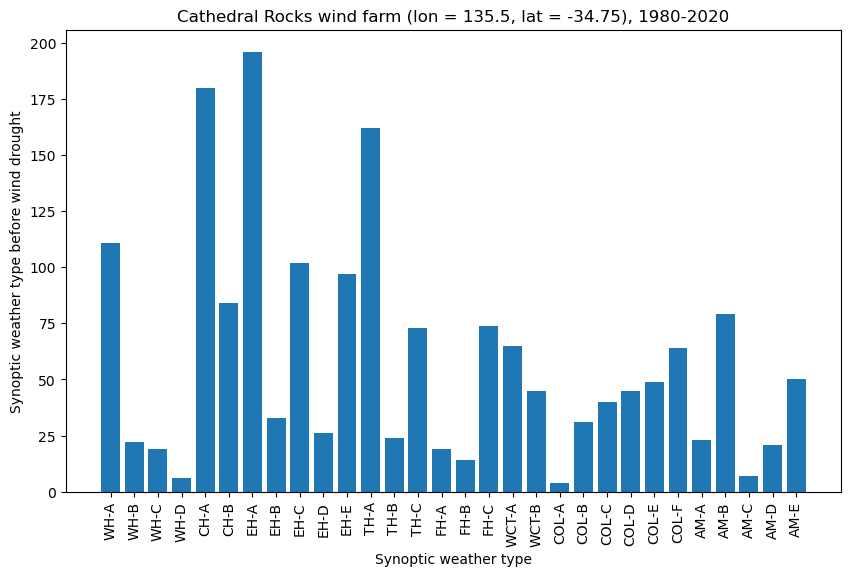

In [134]:
fig = plt.figure(figsize=(10,6))
plt.bar(count_SWT_before_wind_drought.keys(), count_SWT_before_wind_drought.values())
plt.ylabel('Synoptic weather type before wind drought')
plt.title(f'Cathedral Rocks wind farm (lon = {cath_rocks.lon.values}, lat = {cath_rocks.lat.values}), {START_YEAR}-{END_YEAR}')
plt.xticks(rotation=90)
plt.xlabel('Synoptic weather type')
plt.show()

In [135]:
var = 'cf_drought_010'
count_SWT_before_wind_drought_all = {}
for i, SWTname in enumerate(tqdm(SWTnames)):
    SWT_i = clusters[clusters.assigned_SWT == SWTname]
    SWT_time = SWT_i.time - np.timedelta64(1, 'D')
    SWT_time = SWT_time.to_list()
    SWT_time = [t for t in SWT_time if t >= np.datetime64(f'{START_YEAR}-01-01')]
    ds_i = cf_drought.sel(time=SWT_time)
    ds_i_clim = ds_i[var].sum(dim="time")
    SWT_name_str = str(SWTname['SWTs'].to_numpy())
    count_SWT_before_wind_drought_all[SWT_name_str] = ds_i_clim.compute()

100%|██████████| 30/30 [55:03<00:00, 110.12s/it] 


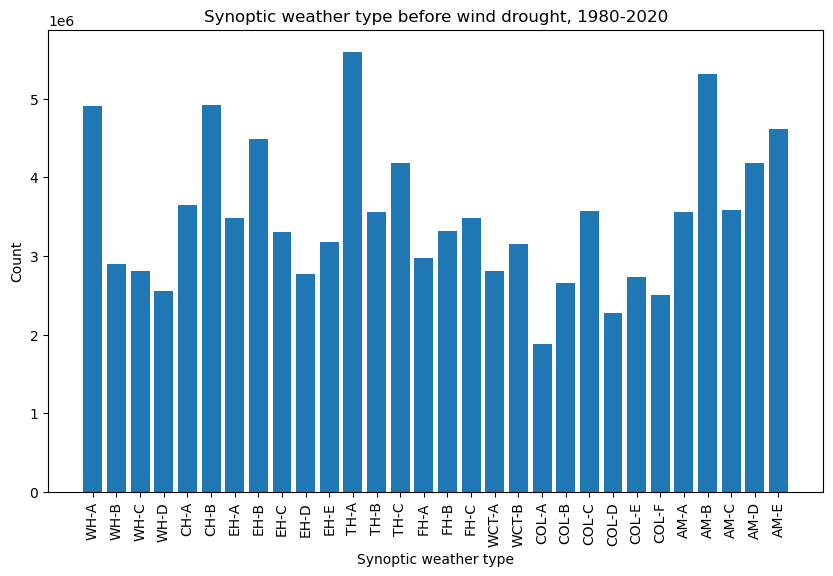

In [138]:
fig = plt.figure(figsize=(10,6))
plt.bar(count_SWT_before_wind_drought_all.keys(), [count_SWT_before_wind_drought_all[k].sum() for k in count_SWT_before_wind_drought_all.keys()])
plt.ylabel('Count')
plt.title(f'Synoptic weather type before wind drought, {START_YEAR}-{END_YEAR}')
plt.xticks(rotation=90)
plt.xlabel('Synoptic weather type')
plt.show()